**Question of focus here: what is the rate of observations needed at the start of the survey (Y1 overall, as well as say first 90 days) to meet the SRD minimum median nvisits requirement at Y10 (750; from Table 23 in [LSST SRD](https://docushare.lsstcorp.org/docushare/dsweb/Get/LPM-17)).**

To answer the question, we look at the median Nvisits at the end of the survey vs the rate of acquiring the visits in Y1 (as well as first 90 days) for a set of sims with varying downtime.

Rate of acquiriing visits is something to define - we go for number of Nvisits in a night / number of night hours in the night. We look at the median of this rate over various windows to probe what window(s) might distinguish sims that meet the Y10 requirements.

In [1]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import sqlite3
from rubin_sim import maf

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# set up the outdir
outdir = 'y1dt'
import os
os.makedirs(outdir, exist_ok=True)

In [4]:
dbpath = '/sdf/data/rubin/shared/fbs_sims/sims_featureScheduler_runs4.1/y1dt'
baselinepath = '/sdf/data/rubin/shared/fbs_sims/sims_featureScheduler_runs4.1/baseline/'
nside = 64

srd_min = 750
srd_med = 825

In [5]:
[f for f in os.listdir(dbpath) if f.endswith('10yrs.db')] + [f for f in os.listdir(baselinepath) if f.endswith('10yrs.db')]

['y1dt_dts1.0_v4.1_10yrs.db',
 'y1dt_dts0.8_v4.1_10yrs.db',
 'y1dt_dts5.0_v4.1_10yrs.db',
 'y1dt_dts2.0_v4.1_10yrs.db',
 'y1dt_dts10.0_v4.1_10yrs.db',
 'y1dt_dts1.5_v4.1_10yrs.db',
 'y1dt_dts0.5_v4.1_10yrs.db',
 'y1dt_dts0.2_v4.1_10yrs.db',
 'baseline_v4.1_10yrs.db']

### lets calculate a few of the metrics we'll look at

In [6]:
%%time

fnovs = None
nvisits_per_night = {}
startmjd = {}
for opsim_fname in [f for f in os.listdir(dbpath) if f.endswith('10yrs.db')] + \
                    [f for f in os.listdir(baselinepath) if f.endswith('10yrs.db')]:
    print(f'\n# working with {opsim_fname}')
    db_tag = opsim_fname.split('_v4.1')[0]
    if db_tag.__contains__('baseline'):
        opsim_path = f'{baselinepath}/{opsim_fname}'
    else:
        opsim_path = f'{dbpath}/{opsim_fname}'

    # first the fov at Y10
    constraint = "scheduler_note not like '%DD%'"
    slicer = maf.slicers.HealpixSlicer(nside=nside)
    metric = maf.metrics.CountExplimMetric(metric_name="fO", exp_col="visitExposureTime")
    summary_metrics = [maf.metrics.FONv(nside=nside, norm=False)]
    
    bundle = maf.MetricBundle(metric, slicer, constraint, summary_metrics=summary_metrics)
    
    bundle_grp = maf.MetricBundleGroup([bundle], opsim_path, out_dir=outdir)
    bundle_grp.run_all()

    if fnovs is None:
        fnovs = pd.DataFrame.from_dict(dict(bundle.summary_values['FONv']), orient='index', columns=[db_tag]).T
    else:
        fnovs = pd.concat([fnovs, pd.DataFrame.from_dict(dict(bundle.summary_values['FONv']), orient='index', columns=[db_tag]).T])

    # ----------------------------------------------------------------------------------------------------------------
    # now the nvisits over y1
    constraint = "scheduler_note not like '%DD%' and night <= 365"
    slicer = maf.slicers.OneDSlicer('night', bin_size=1)
    metric = maf.metrics.CountMetric('observationStartMJD')
    
    nvisits_per_night[db_tag] = maf.MetricBundle(metric, slicer, constraint)
    
    bundle_grp = maf.MetricBundleGroup([nvisits_per_night[db_tag]], opsim_path, out_dir=outdir)
    bundle_grp.run_all()

    # now the startmjd
    conn = sqlite3.connect(opsim_path)
    query = "select observationStartMJD from observations where scheduler_note not like '%DD%' and night <= 365"
    visits = pd.read_sql(query, conn)
    startmjd[db_tag] = np.floor(visits.observationStartMJD.min())


# working with y1dt_dts1.0_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts0.8_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts5.0_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts2.0_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts10.0_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts1.5_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts0.5_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with y1dt_dts0.2_v4.1_10yrs.db
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes

# working with baseline_v4.1_10yrs.db
Healpix slicer using NSI

lets add the downtime scale as a column to clearly identify the various sims

In [7]:
# add tags for the downtime - using dbnames is too much
dt = []
for db in fnovs.index:
    if db.__contains__('baseline'):
        dt.append(np.nan)
    else:
        dt.append(float(db.split('dts')[-1]))
fnovs['dt scale'] = dt

# lets also sort things by this downtime
fnovs.sort_values(by=['dt scale'], ascending=False, inplace=True)
fnovs

,MedianNvis,MinNvis,dt scale
y1dt_dts10.0,750.0,698.0,10.0
y1dt_dts5.0,751.0,700.0,5.0
y1dt_dts2.0,757.0,706.0,2.0
y1dt_dts1.5,762.0,711.0,1.5
y1dt_dts1.0,773.0,721.0,1.0
y1dt_dts0.8,775.0,722.0,0.8
y1dt_dts0.5,779.0,726.0,0.5
y1dt_dts0.2,789.0,736.0,0.2
baseline,779.0,726.0,NaN


note that baseline appears to be the same dts0.5 .. so lets just drop it. we can add an asterisk to dts0.5 to help us remember that this is the baseline.

In [8]:
fnovs.drop('baseline', inplace=True)
fnovs.rename(index={'y1dt_dts0.5': 'y1dt_dts0.5*'}, inplace=True)
nvisits_per_night['y1dt_dts0.5*'] = nvisits_per_night.pop('y1dt_dts0.5')
fnovs

,MedianNvis,MinNvis,dt scale
y1dt_dts10.0,750.0,698.0,10.0
y1dt_dts5.0,751.0,700.0,5.0
y1dt_dts2.0,757.0,706.0,2.0
y1dt_dts1.5,762.0,711.0,1.5
y1dt_dts1.0,773.0,721.0,1.0
y1dt_dts0.8,775.0,722.0,0.8
y1dt_dts0.5*,779.0,726.0,0.5
y1dt_dts0.2,789.0,736.0,0.2


<Figure size 640x480 with 0 Axes>

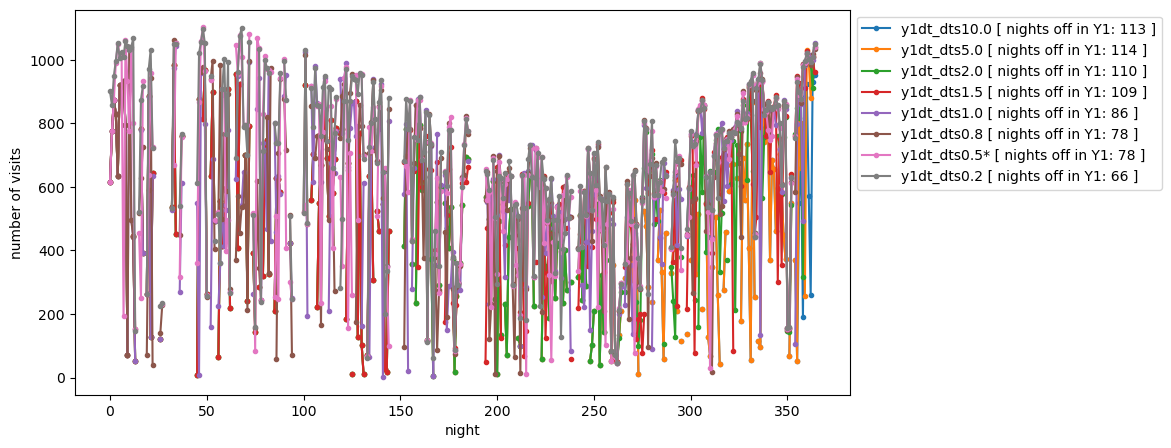

In [9]:
# lets plot the number of number of visits in a night to what things look like
plt.clf()
fig, ax = plt.subplots(1,1)
for i, db in enumerate(fnovs.index):
    ax.plot(nvisits_per_night[db].metric_values, '.-',
            label=f'{db} [ nights off in Y1: {len(nvisits_per_night[db].metric_values) - len(nvisits_per_night[db].metric_values.compressed())} ]')
    
# plot details
ax.set_ylabel('number of visits')
ax.set_xlabel('night')
ax.legend(bbox_to_anchor=(1,1))
fig.set_size_inches(10,5)
plt.show()

ok so we have gaps - for nights where no observations were taken. the number of nights off (shown in the legend) changes with `dt_scale` but it is not a distinguishing feature across all the sims.

it could be nice to have the max nvisits possible for each night on this plot - but will need to look into a metric to get the number of hours available for observing, to plot alongside number of hours avialable in the night, as a proxy for visualizing downtime. something for the future.

### lets plot the MedianNvis and compare to the SRD requirement

/lscratch/humna/ipykernel_1885901/1652979094.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(fnovs['dt scale'].values)


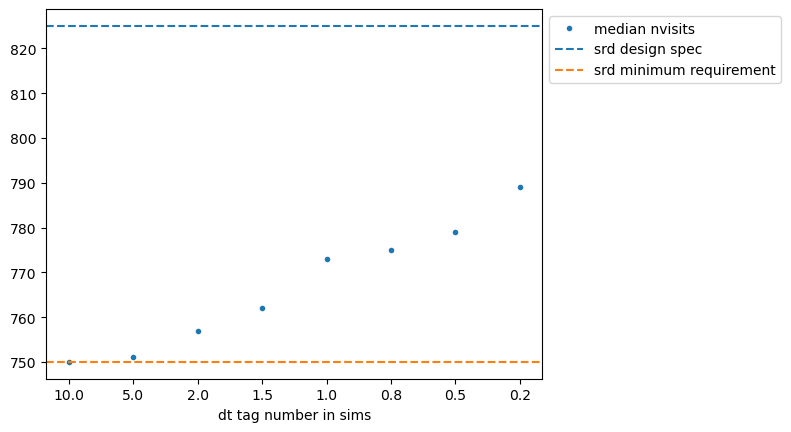

In [10]:
plt.clf()
plt.plot(fnovs['MedianNvis'], '.', label='median nvisits')
plt.axhline(srd_med, color='C0', ls='--', label='srd design spec')
plt.axhline(srd_min, ls='--', color='C1', label='srd minimum requirement')
plt.legend(bbox_to_anchor=(1,1))
plt.gca().set_xticklabels(fnovs['dt scale'].values)
plt.xlabel('dt tag number in sims')
plt.show()

okay so we have one sim that is exactly at the requirement but no sims are below the requirement .. this is not super helpful to see what rate is _necessary_ to meet the requirement but lets see how far we can get with the sims we have rn.

#### lets calculate the night length to get an estimate for rate of acquiring visits

In [11]:
# startmjds seem to be the same for all sims - lets just add a flag in case this assumption breaks in the future
if len(np.unique(startmjd.values())) != 1:
    raise ValueError(f'different startmjds?????: {startmjd}')

In [12]:
from rubin_scheduler.site_models import Almanac

almanac = Almanac(list(startmjd.values())[0])
start_idx = np.where(almanac.sunsets['night'] == 0)[0][0]

# lets pick the settings with 18deg
sunsets = almanac.sunsets[start_idx : start_idx + 365]['sun_n18_setting']
sunrises = almanac.sunsets[start_idx : start_idx + 365]['sun_n18_rising']
# calculate night hours
night_hours = (sunrises - sunsets) * 24

## plot the rate of acquiring visits as a function - as well the median and other stats over Y1

we define the rate as simply Nvisits per night / hours in the night

<Figure size 640x480 with 0 Axes>

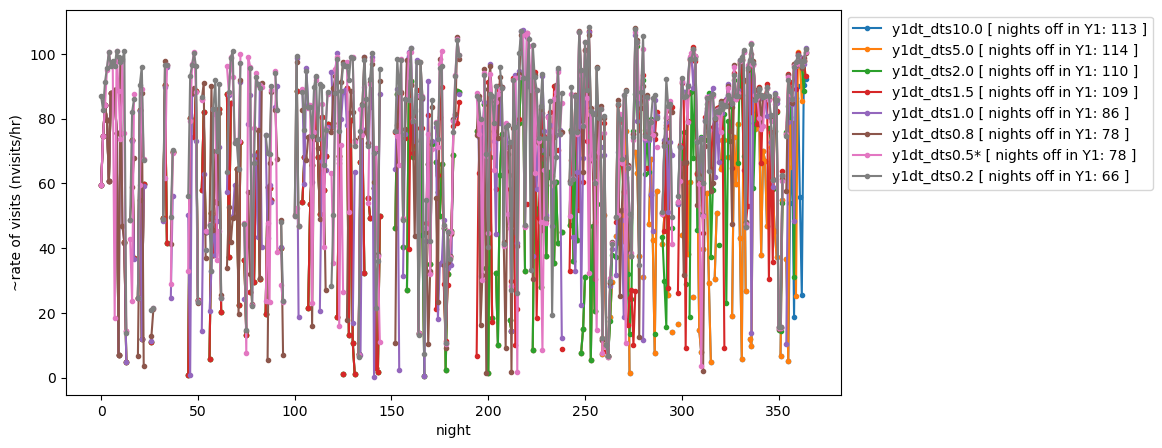

In [13]:
# rate of acquiring visits as a function of time
plt.clf()
fig, ax = plt.subplots(1,1)

for i, db in enumerate(fnovs.index):
    rate = nvisits_per_night[db].metric_values/night_hours
    # print(db, len(rate), len(rate.compressed()))
    # rate = rate.compressed()
    ax.plot(rate, '.-', label=f'{db} [ nights off in Y1: {len(rate) - len(rate.compressed())} ]')

ax.set_ylabel('~rate of visits (nvisits/hr)')
ax.set_xlabel('night')
ax.legend(bbox_to_anchor=(1,1))
fig.set_size_inches(10,5)
plt.show()

ok so we have the rate - curves dont change too much from number of visits plot above.

<Figure size 640x480 with 0 Axes>

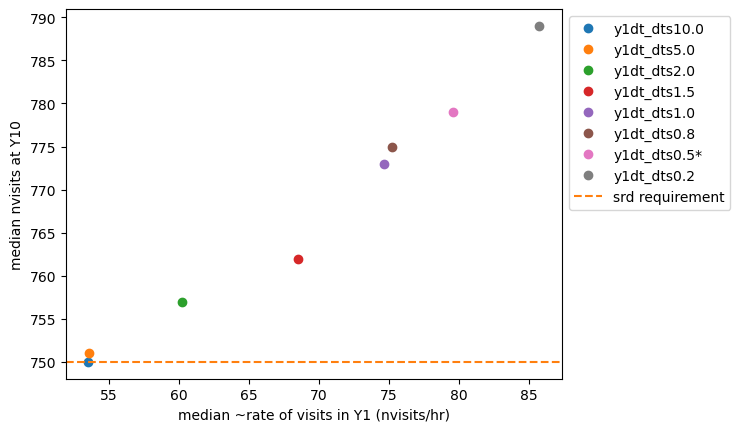

In [14]:
# now lets plot the median
data_for_box = None
plt.clf()
fig, ax = plt.subplots(1,1)
for i, db in enumerate(fnovs.index):
    rate = nvisits_per_night[db].metric_values/night_hours
    rate = rate.compressed()
    
    ax.plot(np.median(rate), fnovs.iloc[i, 0], 'o', label=db)

    if data_for_box is None:
        data_for_box = [rate]
    else:
        data_for_box.append(rate)


ax.axhline(srd_min, ls='--', color='C1', label='srd requirement')
ax.set_ylabel('median nvisits at Y10')
ax.set_xlabel('median ~rate of visits in Y1 (nvisits/hr)')

ax.legend(bbox_to_anchor=(1,1))
plt.show()

ok we see that the higher downtime scale means lower median nvisits at Y10. it would nice to get a sense of the range of Nvisits - so lets try to create a box plot.

<Figure size 640x480 with 0 Axes>

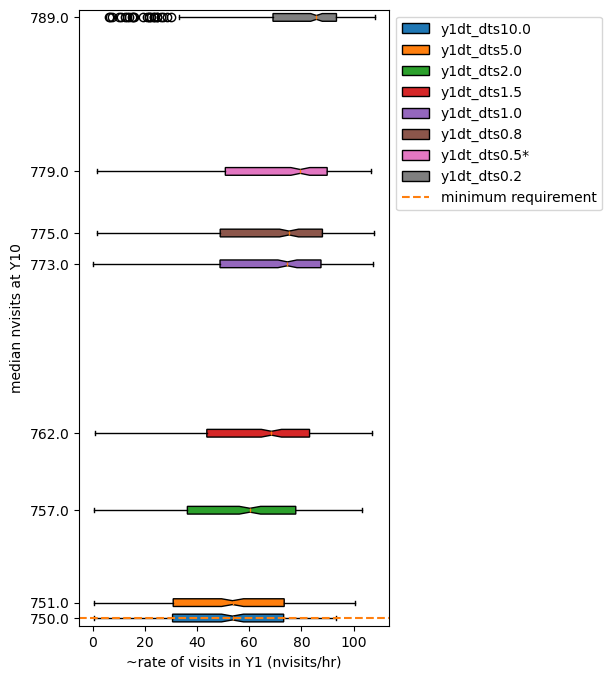

In [15]:
# now lets plot
plt.clf()
fig, ax = plt.subplots(1, 1)
bp = ax.boxplot(data_for_box, vert=False, positions=fnovs['MedianNvis'].values,
                showfliers=True, notch=True, patch_artist=True,
               )
for i, box in enumerate(bp['boxes']):
    box.set(facecolor=f'C{i}', label=fnovs.index[i])

ax.axhline(srd_min, ls='--', color='C1', label='minimum requirement')
ax.set_ylabel('median nvisits at Y10')
ax.set_xlabel('~rate of visits in Y1 (nvisits/hr)')

ax.legend(bbox_to_anchor=(1,1))
fig.set_size_inches(4, 8)
plt.show()

ok so the range doesnt seem to change too much with dt-scalor, except for dts0.2 (which also seems to have outliers, which other sims dont).

### now lets look at the median rate over various windows

this will help us see if any specific window of nights helps tweeze out what sims lead to Y10 meeting SRD reqs.

<Figure size 640x480 with 0 Axes>

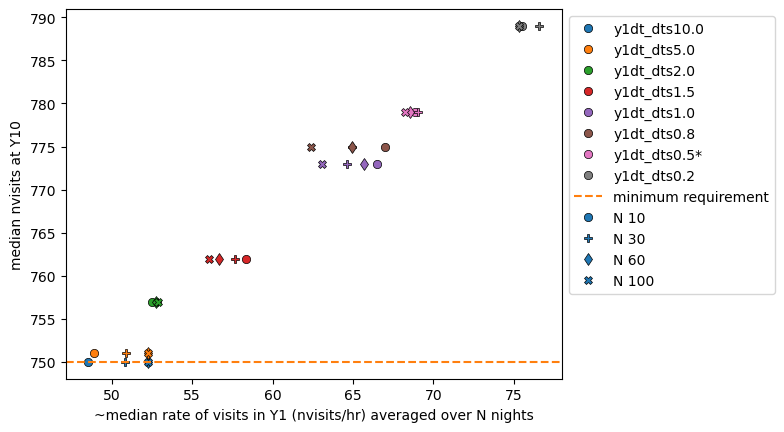

In [16]:
# lets look at things with a moving window
figlines = []
syms = ['o', 'P', 'd', 'X', '*']
window_sizes = [10, 30, 60, 100]

plt.clf()
fig, ax = plt.subplots(1, 1)
for wi, window_size in enumerate(window_sizes):
    # loop over the dbs
    for i, db in enumerate(fnovs.index):
        # initate the data-holders
        window, averages = [], []
        # loop over the nights
        for j in nvisits_per_night[db].metric_values/night_hours:
            if isinstance(j, float):
                # add this data point into the window
                window.append(j)
            if len(window) > window_size:
                # remove the oldest sample from the window once it reaches the desired size
                window.pop(0)
            # get the average in this window
            averages.append( sum(window) / float(len(window)) )
        # now plot the average in each window
        if wi == 0:
            label = db
        else:
            label = None
        # plot
        p0, = ax.plot(np.median(averages), fnovs.iloc[i, 0], syms[wi], color=f'C{i}', label=label, markeredgecolor='k', markeredgewidth=0.5)
        # save plot obj to add legend later
        if i == 0:
            figlines.append(p0)
# plot details
ax.axhline(srd_min, ls='--', color='C1', label='minimum requirement')
ax.set_ylabel('median nvisits at Y10')
ax.set_xlabel(f'~median rate of visits in Y1 (nvisits/hr) averaged over N nights')
ax.legend()
# update the legend
handles, labels = ax.get_legend_handles_labels()
handles += figlines
labels += [f'N {f}' for f in window_sizes]
ax.legend(handles, labels, bbox_to_anchor=(1,1))

plt.show()

ok this plot is a bit busy but we see that the median rate doesnt change too dramatically with different windows. lets plot things as a function of windows explicity.

<Figure size 640x480 with 0 Axes>

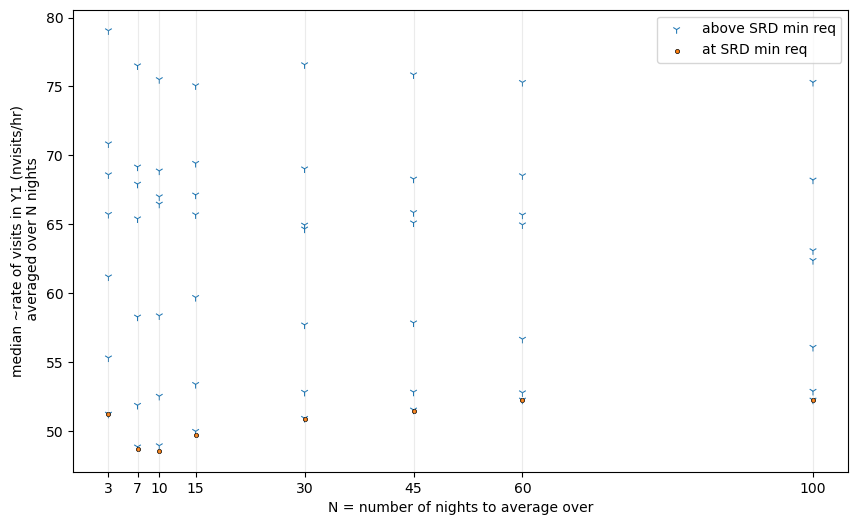

In [17]:
# lets calculate data for some more window sizes for this plot
window_sizes = [3, 7, 10, 15, 30, 45, 60, 100]
nwindows = len(window_sizes)

data_for_later = {}
data_for_box = {}
for wi, window_size in enumerate(window_sizes):
    # loop over the dbs
    for i, db in enumerate(fnovs.index):
        # initate the data-holders
        window, averages = [], []
        # loop over the nights
        for j in nvisits_per_night[db].metric_values/night_hours:
            if isinstance(j, float):
                # add this data point into the window
                window.append(j)
            if len(window) > window_size:
                # remove the oldest sample from the window once it reaches the desired size
                window.pop(0)
            # get the average in this window
            averages.append( sum(window) / float(len(window)) )

        if window_size not in data_for_later:
            data_for_later[window_size] = []
            data_for_box[window_size] = []
        data_for_later[window_size].append(np.median(averages))
        if len(data_for_box[window_size]) == 0:
            data_for_box[window_size] = [averages]
        else:
            data_for_box[window_size].append(averages)

# now plot
srd_met = fnovs.iloc[:, 0].values > srd_min

plt.clf()
fig, ax = plt.subplots(1, 1)
for window in data_for_later:
    inds = np.where(srd_met)[0]
    ax.scatter([window] * len(inds), np.array(data_for_later[window])[inds], #alpha=0.75,
               color=['C0' if x else 'C1' for x in srd_met[inds]], marker='1', linewidths=0.75,
               label='above SRD min req'
              )
    inds = np.where(~srd_met)[0]
    ax.scatter([window] * len(inds), np.array(data_for_later[window])[inds], #alpha=0.75,
               color=['C0' if x else 'C1' for x in srd_met[inds]], marker='.', edgecolors='k', linewidths=0.5,
               label='at SRD min req'
              )

# update legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], bbox_to_anchor=(1,1))
# details
ax.set_xlabel('N = number of nights to average over')
ax.set_ylabel('median ~rate of visits in Y1 (nvisits/hr)\n averaged over N nights')
ax.set_xticks(list(data_for_later.keys()), list(data_for_later.keys()))
ax.grid(axis='x', alpha=0.25)

fig.set_size_inches(10, 6)
plt.show()

given that we dont have any sims that dont meet the Y10 requirements, its a bit difficult to really say what the minimum required rate of acquiring observations in Y1 is - but it seems from this plot that a median rate of acquiring visits in Y1 (nvisits/hr) >~ 50 when averaged over 7-10 nights should be okay.

lets plot the windowed rate of visits as a function of time (Y1) to see if we can distinguish the various sims.

<Figure size 640x480 with 0 Axes>

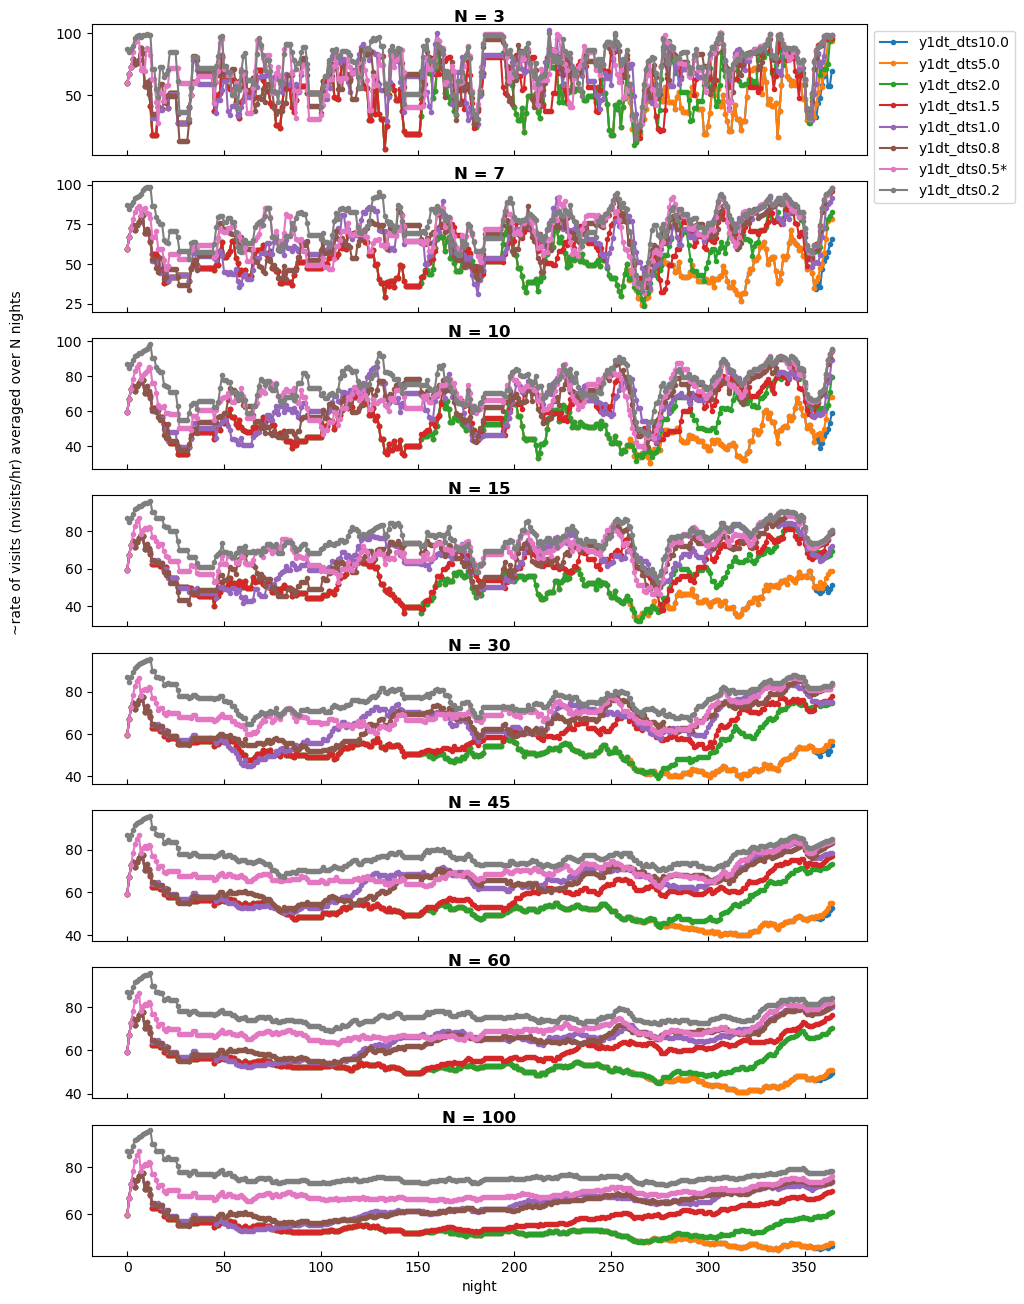

In [18]:
plt.clf()
fig, axes = plt.subplots(nwindows, 1)
plt.subplots_adjust(hspace=0.2)

for wi, window_size in enumerate(data_for_box):
    for i, db in enumerate(fnovs.index):
        axes[wi].plot(data_for_box[window_size][i], '.-', label=db)
        if i == 0:
            axes[wi].set_title(f'N = {window_size}', fontweight='bold', y=0.95)
        if wi != nwindows-1:
            axes[wi].set_xticklabels([])
        
for k in range(nwindows):
    axes[k].tick_params(axis="x", direction="in")
axes[-1].set_xlabel('night')
axes[0].legend(bbox_to_anchor=(1,1))
fig.text(0.05, 0.5, f'~rate of visits (nvisits/hr) averaged over N nights', ha='center', rotation='vertical')
fig.set_size_inches(10, nwindows*2)
plt.show()

plt.show()

ok so the `dt_scale` impacts for >1 values are really only distinguishable later in Y1 (after night ~150). the curves become a bit more distguishable with windowing range, N = 45-60 days. N = 3 is too noisy; N = 7-10 starts some separating out some of the sims.

lets also see what the whisker plot looks like for different windows. this should help get a sense of the variation in the rate over Y1.

<Figure size 640x480 with 0 Axes>

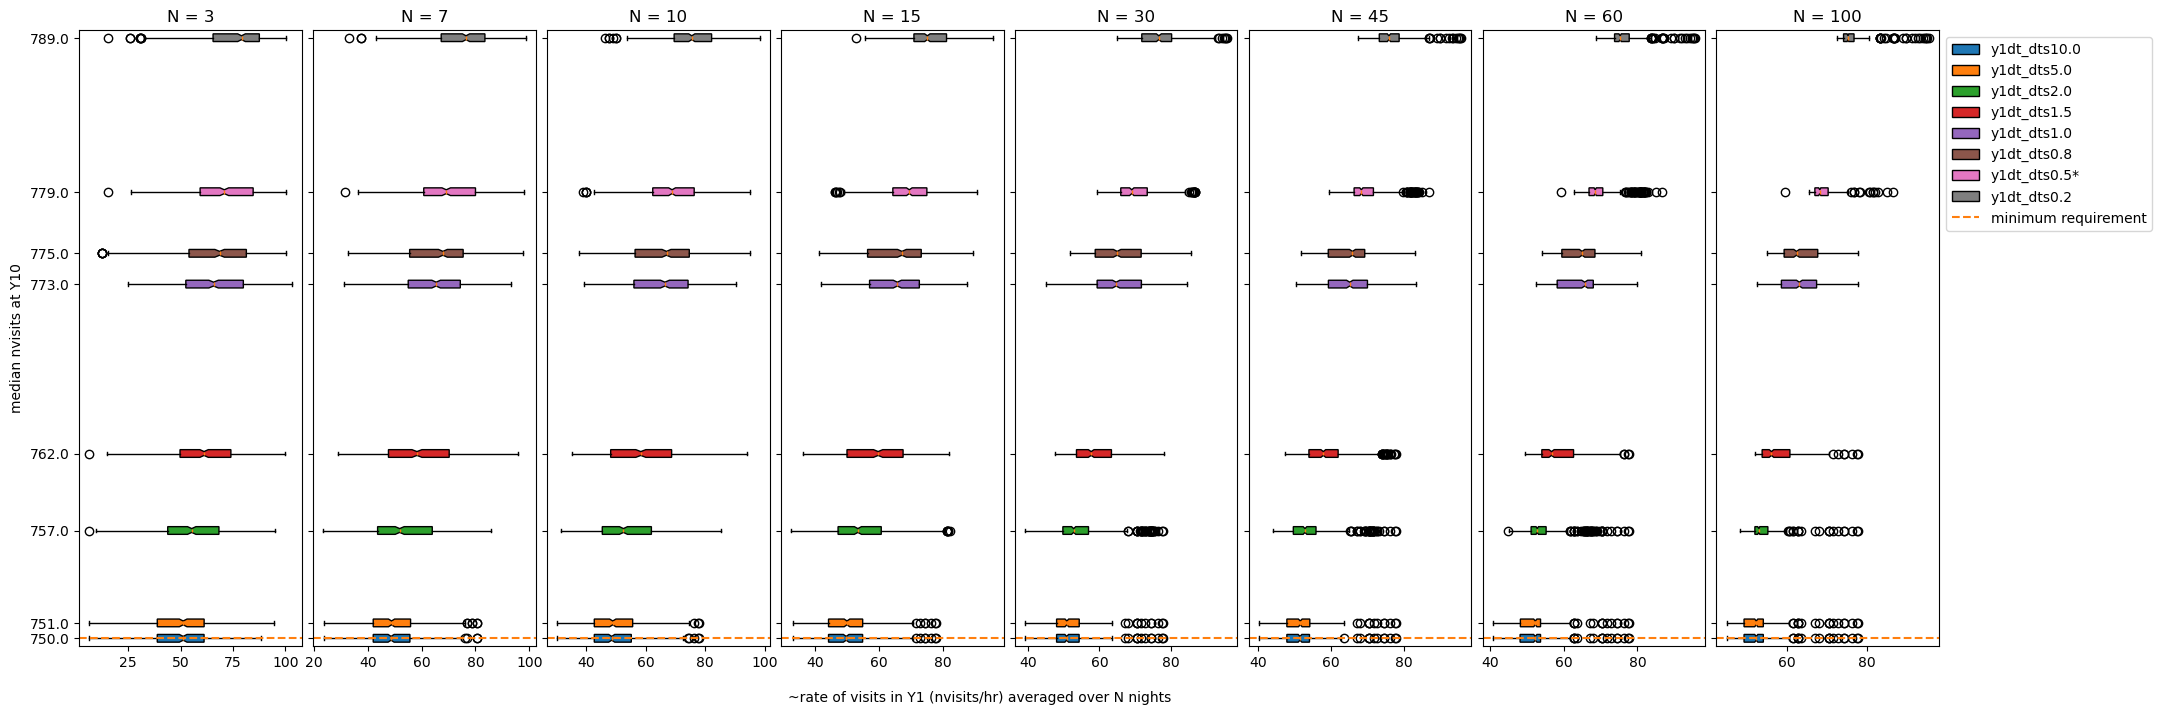

In [19]:
# now lets plot things for each window
plt.clf()
fig, axes = plt.subplots(1, nwindows)
plt.subplots_adjust(wspace=0.05)
for wi, window_size in enumerate(data_for_box):
    bp = axes[wi].boxplot(data_for_box[window_size], vert=False, positions=fnovs['MedianNvis'].values,
                    showfliers=True, notch=True, patch_artist=True,
                   )
    for i, box in enumerate(bp['boxes']):
        box.set(facecolor=f'C{i}', label=fnovs.index[i])
    
    axes[wi].axhline(srd_min, ls='--', color='C1', label='minimum requirement')
    axes[wi].set_title(f'N = {window_size}')
    
    if wi != 0:
        axes[wi].set_yticklabels([])
        
axes[0].set_ylabel('median nvisits at Y10')
axes[-1].legend(bbox_to_anchor=(1,1))
fig.text(0.5, 0.04, '~rate of visits in Y1 (nvisits/hr) averaged over N nights', ha='center')

fig.set_size_inches(nwindows*3, 8)
plt.show()

ok the variation is ~comparable between N7-15, N30-45, N60-100, decreasing as N grows.

### repeat above - but now only for first three months of Y1

<Figure size 640x480 with 0 Axes>

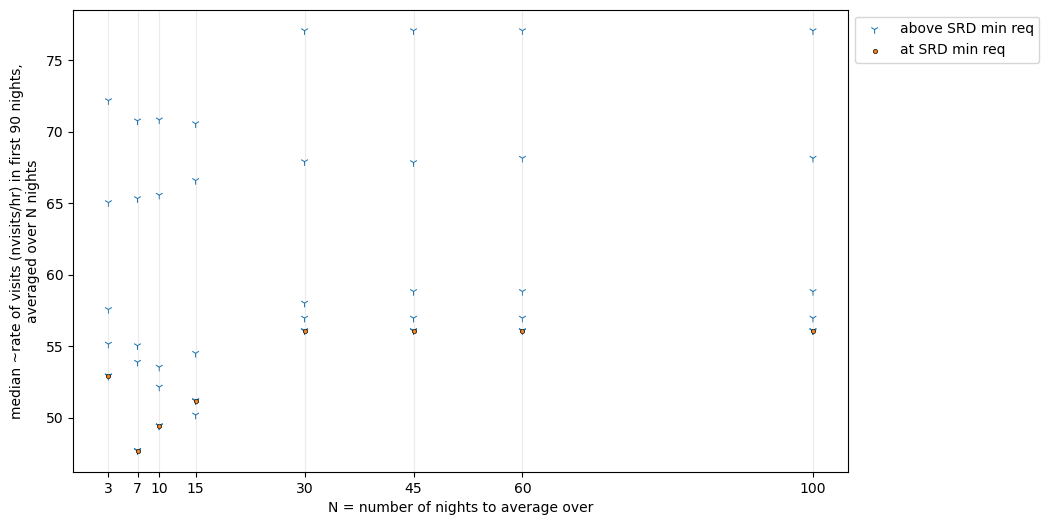

In [20]:
night_threshold = 90

# same calculation as above
data_for_later = {}
data_for_box = {}

for wi, window_size in enumerate(window_sizes):
    # loop over the dbs
    for i, db in enumerate(fnovs.index):
        # initate the data-holders
        window, averages = [], []
        # loop over the nights
        for night_index, j in enumerate(nvisits_per_night[db].metric_values/night_hours):
            if night_index < night_threshold:
                if isinstance(j, float):
                    # add this data point into the window
                    window.append(j)
                if len(window) > window_size:
                    # remove the oldest sample from the window once it reaches the desired size
                    window.pop(0)
                # get the average in this window
                averages.append( sum(window) / float(len(window)) )

        if window_size not in data_for_later:
            data_for_later[window_size] = []
            data_for_box[window_size] = []
        data_for_later[window_size].append(np.median(averages))
        if len(data_for_box[window_size]) == 0:
            data_for_box[window_size] = [averages]
        else:
            data_for_box[window_size].append(averages)

# now plot
srd_met = fnovs.iloc[:, 0].values > srd_min

plt.clf()
fig, ax = plt.subplots(1, 1)
for window in data_for_later:
    inds = np.where(srd_met)[0]
    ax.scatter([window] * len(inds), np.array(data_for_later[window])[inds], #alpha=0.75,
               color=['C0' if x else 'C1' for x in srd_met[inds]], marker='1', linewidths=0.75,
               label='above SRD min req'
              )
    inds = np.where(~srd_met)[0]
    ax.scatter([window] * len(inds), np.array(data_for_later[window])[inds], #alpha=0.75,
               color=['C0' if x else 'C1' for x in srd_met[inds]], marker='.', edgecolors='k', linewidths=0.5,
               label='at SRD min req'
              )

# update legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], bbox_to_anchor=(1,1))
# details
ax.set_xlabel('N = number of nights to average over')
ax.set_ylabel(f'median ~rate of visits (nvisits/hr) in first {night_threshold} nights,\naveraged over N nights')
ax.set_xticks(list(data_for_later.keys()), list(data_for_later.keys()))
ax.grid(axis='x', alpha=0.25)

fig.set_size_inches(10, 6)
plt.show()

ok as above, its difficult to really be definitive about rate of visits needed at the start of Y1 without at least some sims not meeting the Y10 reqs - but a median rate of acquiring >~50 nvisits/hr, when averaged over 7-15 nights should be okay.

and now the rate as a function of night (effectively a zoom in of the plot above):

<Figure size 640x480 with 0 Axes>

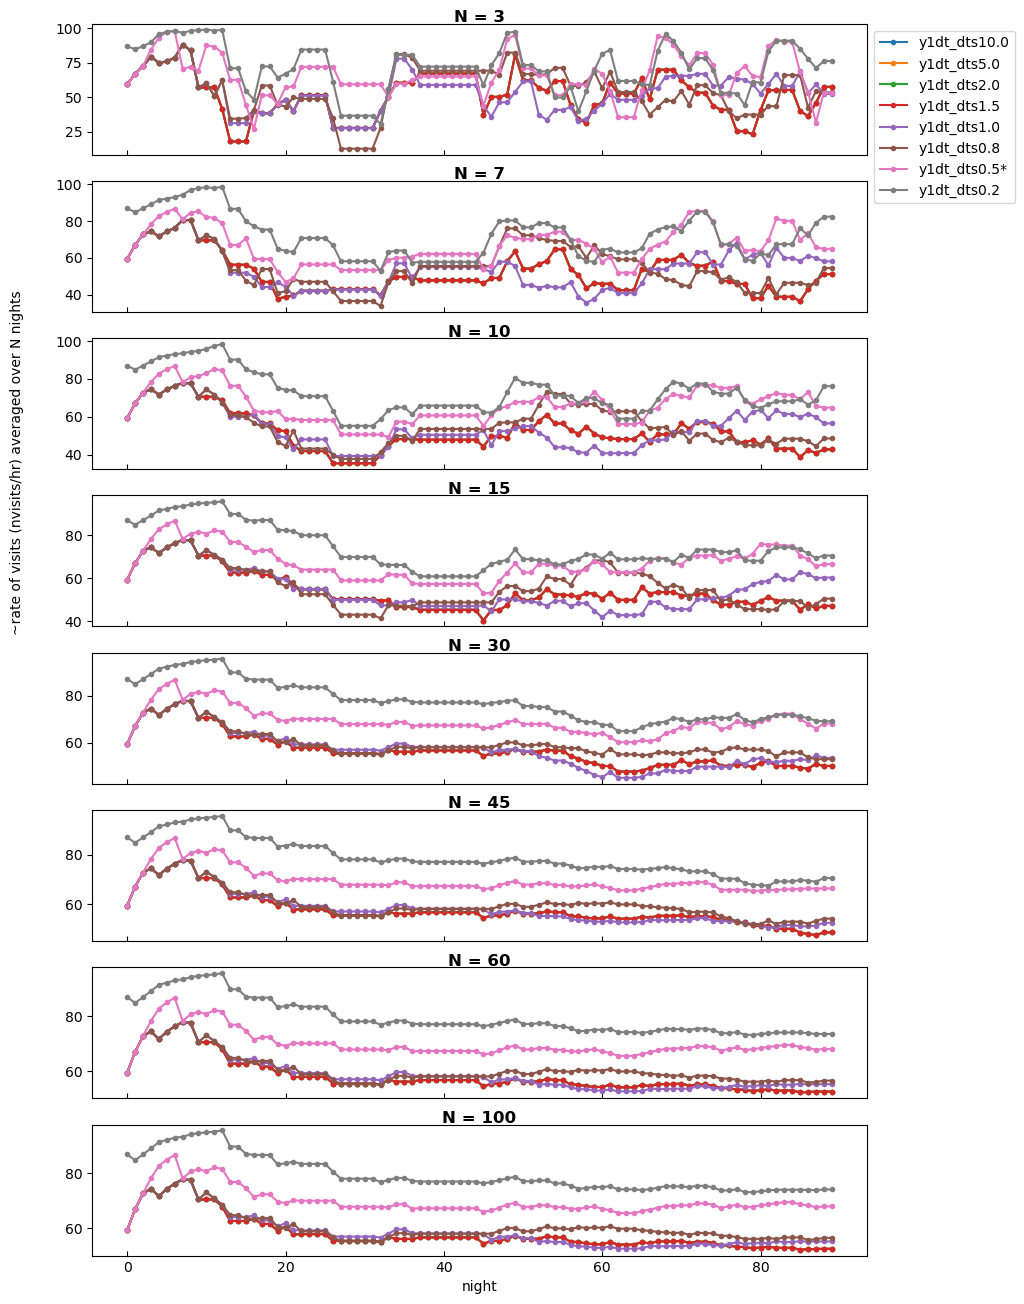

In [21]:
plt.clf()
fig, axes = plt.subplots(nwindows, 1)
plt.subplots_adjust(hspace=0.2)

for wi, window_size in enumerate(data_for_box):
    for i, db in enumerate(fnovs.index):
        axes[wi].plot(data_for_box[window_size][i], '.-', label=db)

        if i == 0:
            axes[wi].set_title(f'N = {window_size}', fontweight='bold', y=0.95)
    
        if wi != nwindows-1:
            axes[wi].set_xticklabels([])
        
        
for k in range(nwindows):
    axes[k].tick_params(axis="x", direction="in")

axes[-1].set_xlabel('night')

axes[0].legend(bbox_to_anchor=(1,1))
fig.text(0.05, 0.5, f'~rate of visits (nvisits/hr) averaged over N nights', ha='center', rotation='vertical')

fig.set_size_inches(10, nwindows*2)
plt.show()

plt.show()

as above, the `dt_scale` impacts for >1 (here 1.5, really) are not distinsuighable for the first 90 days. windowing range of 7-10 starts separting things out but the smoothness isnt consistent until N=30, which seems a bit quite long.

and finally, the whisker plots.

<Figure size 640x480 with 0 Axes>

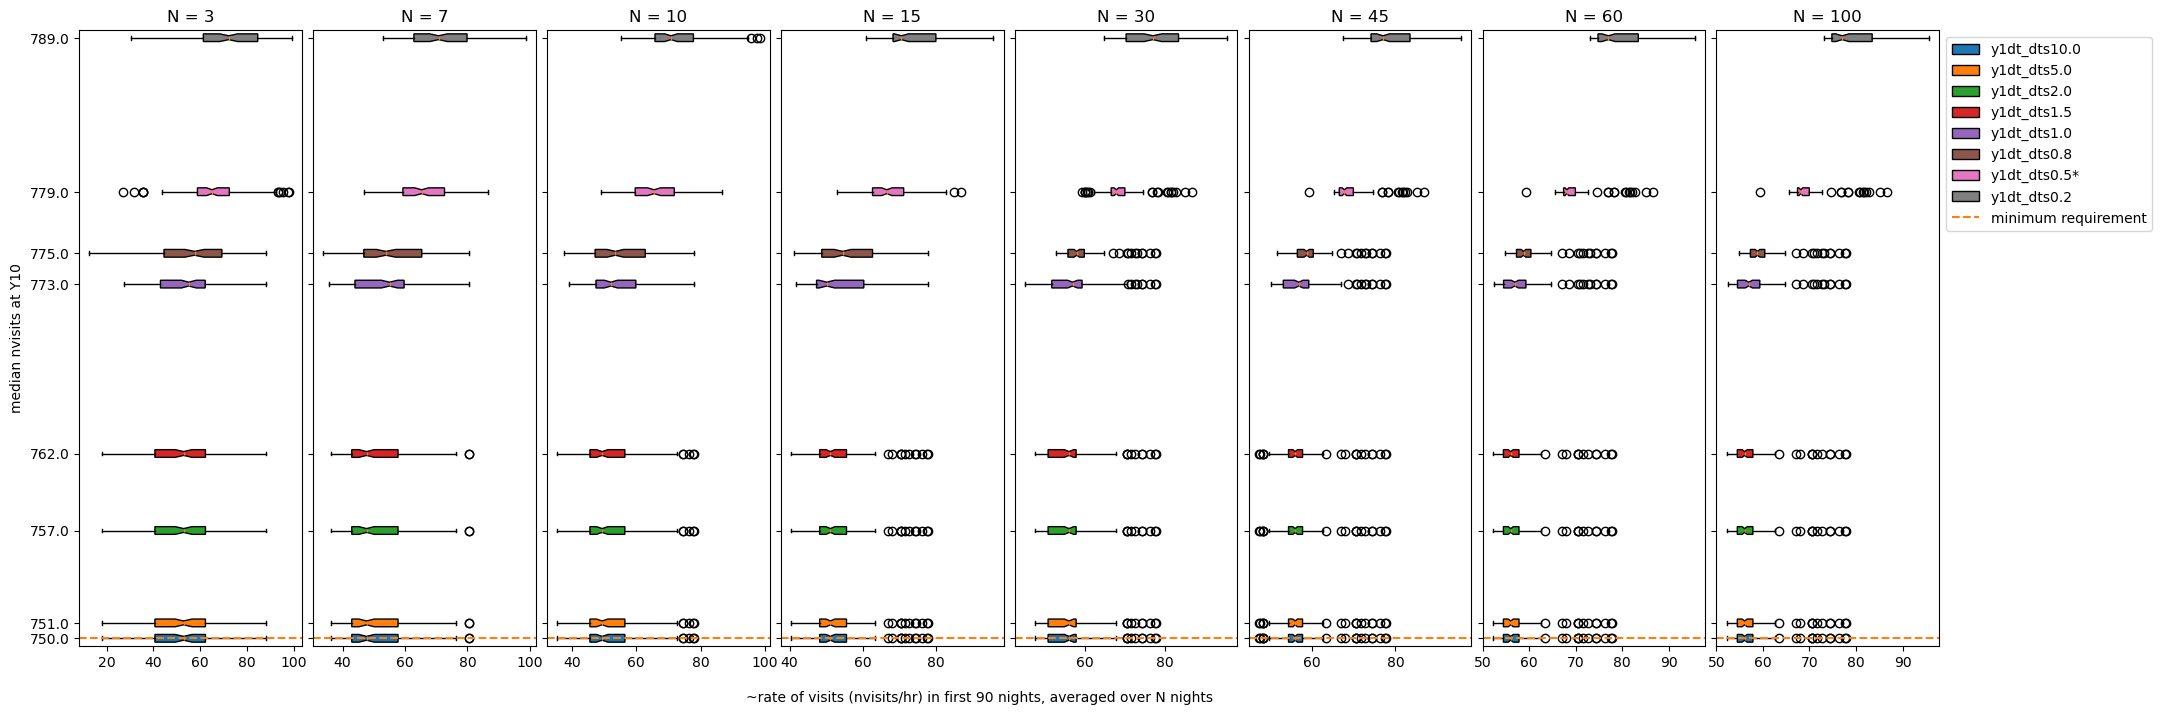

In [22]:
# now lets plot things for each window
plt.clf()
fig, axes = plt.subplots(1, nwindows)
plt.subplots_adjust(wspace=0.05)
for wi, window_size in enumerate(data_for_box):
    bp = axes[wi].boxplot(data_for_box[window_size], vert=False, positions=fnovs['MedianNvis'].values,
                    showfliers=True, notch=True, patch_artist=True,
                   )
    for i, box in enumerate(bp['boxes']):
        box.set(facecolor=f'C{i}', label=fnovs.index[i])
    
    axes[wi].axhline(srd_min, ls='--', color='C1', label='minimum requirement')
    axes[wi].set_title(f'N = {window_size}')
    
    if wi != 0:
        axes[wi].set_yticklabels([])
        
axes[0].set_ylabel('median nvisits at Y10')
axes[-1].legend(bbox_to_anchor=(1,1))
fig.text(0.5, 0.04, f'~rate of visits (nvisits/hr) in first {night_threshold} nights, averaged over N nights', ha='center')

fig.set_size_inches(nwindows*3, 8)
plt.show()

similar results as above - we see smaller variation, although with outliers, for large N. variation is comparable between N3-7, N7-15.

we'll pause the analysis here. for further study, we need sims with more downtime - and perhaps with different downtime implementations. for now, it seems that we'd be on track to meet Y10 SRD reqs on median Nvisits if we maintain a median rate of acquiring >~50 nvisits/hr, when averaged over 7-15 nights, both over first 90 days in Y1 and Y1 overall.